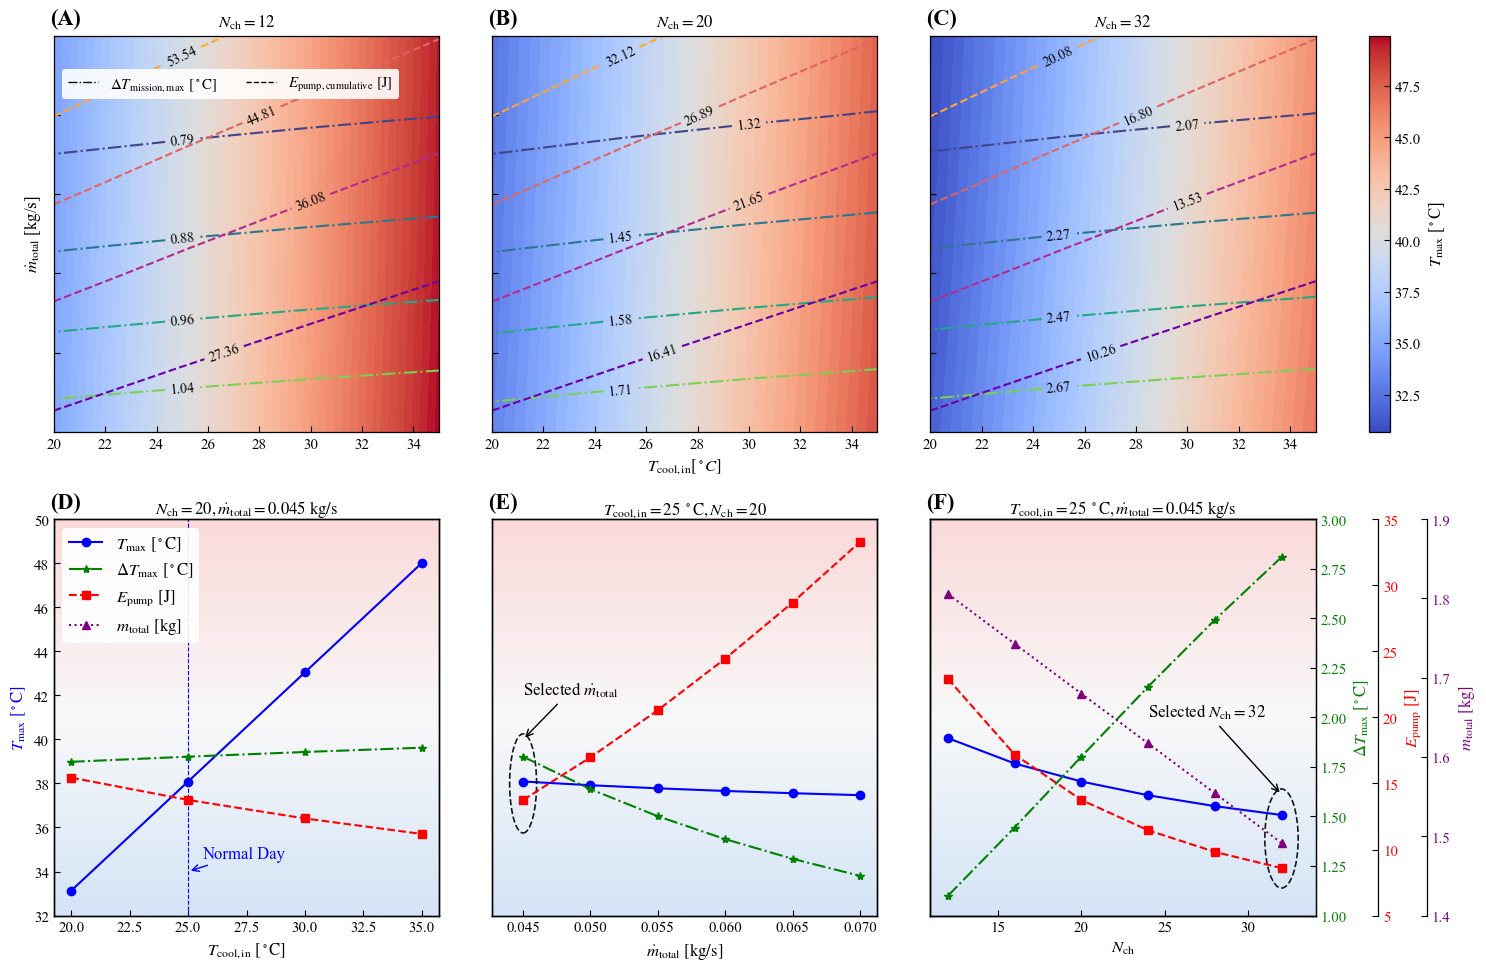

Combined plot saved to: d:\eBATS\out\C0003\C0003_PARK25_LC_1D_SCAN_plot.png
Combined plot saved to: d:\eBATS\out\C0003\C0003_PARK25_LC_1D_SCAN_plot.pdf


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import os
import sys
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse

# -----------------------------------------------------------------------------
# Data file and utility setup
# -----------------------------------------------------------------------------
root_dir = os.path.abspath("../..")
sys.path.append(root_dir)

import lib.plot_util as plot_util

CASE_ID = "C0003"
CASE_NAME = "C0003R02_PARK25_LC_1D_SCAN"
data_file = os.path.join(root_dir, "data", CASE_ID, f"{CASE_NAME}.xlsx")
sheet_name = "Parameter scan"
data = pd.read_excel(data_file, sheet_name=sheet_name)

for column in [
    'm_dot_total_kg_s', 'T_water_in_C', 'Dh_mm', 'num_parallel_channels',
    'Tmax_mission_C', 'DeltaT_mission_max_C', 'P_pump', 'm_plate_kg',
    'm_coolant_kg', 'mtotal'
]:
    data[column] = pd.to_numeric(data[column], errors='raise')

def label_fmt(x):
    return f"{x:.2f}"

# -----------------------------------------------------------------------------
# Plot style
# -----------------------------------------------------------------------------
base_fontsize = 12
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'stix',
    'font.size': base_fontsize,
    'axes.labelsize': base_fontsize,
    'axes.titlesize': base_fontsize,
    'xtick.labelsize': base_fontsize * 0.9,
    'ytick.labelsize': base_fontsize * 0.9,
    'axes.linewidth': 0.9,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'axes.unicode_minus': False,
})

# -----------------------------------------------------------------------------
# Create the combined A-F figure
# -----------------------------------------------------------------------------
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(
    2, 4,
    width_ratios=[1.0, 1.0, 1.0, 0.055],
    height_ratios=[1.0, 1.0],
    left=0.065, right=0.90, bottom=0.075, top=0.955,
    wspace=0.18, hspace=0.22
)
ax_A = fig.add_subplot(gs[0, 0])
ax_B = fig.add_subplot(gs[0, 1], sharex=ax_A, sharey=ax_A)
ax_C = fig.add_subplot(gs[0, 2], sharex=ax_A, sharey=ax_A)
cax = fig.add_subplot(gs[0, 3])
ax_D = fig.add_subplot(gs[1, 0])
ax_E = fig.add_subplot(gs[1, 1])
ax_F = fig.add_subplot(gs[1, 2])

# -----------------------------------------------------------------------------
# Top row: contour plots (A-C)
# -----------------------------------------------------------------------------
D_h_selected = 4.3636
thermal_data = data[np.isclose(data['Dh_mm'], D_h_selected)].copy()
key_N_ch = 'num_parallel_channels'
key_x = 'T_water_in_C'
key_y = 'm_dot_total_kg_s'
key_val_T = 'Tmax_mission_C'
key_val_dT = 'DeltaT_mission_max_C'
key_val_E = 'E_pump_cumulative'
N_ch_array = [12, 20, 32]
T_max = thermal_data[key_val_T].max()
T_min = thermal_data[key_val_T].min()
ax_dict = [ax_A, ax_B, ax_C]

for i, N_ch in enumerate(N_ch_array):
    ax = ax_dict[i]
    thermal_data_N_ch = thermal_data[thermal_data[key_N_ch] == N_ch]
    x_values = sorted(thermal_data_N_ch[key_x].unique())
    y_values = sorted(thermal_data_N_ch[key_y].unique())
    Z_values_T = thermal_data_N_ch.pivot(index=key_y, columns=key_x, values=key_val_T).values
    Z_values_dT = thermal_data_N_ch.pivot(index=key_y, columns=key_x, values=key_val_dT).values
    Z_values_E = thermal_data_N_ch.pivot(index=key_y, columns=key_x, values=key_val_E).values
    dT_max = Z_values_dT.max()
    dT_min = Z_values_dT.min()
    E_max = Z_values_E.max()
    E_min = Z_values_E.min()

    ax.contourf(x_values, y_values, Z_values_T, levels=50, cmap=sns.color_palette('coolwarm', as_cmap=True), vmin=T_min, vmax=T_max)

    levels_dT = np.arange(dT_min, dT_max + (dT_max - dT_min) / 5, (dT_max - dT_min) / 5)
    cs = ax.contour(x_values, y_values, Z_values_dT, levels=levels_dT, cmap=sns.color_palette('viridis', as_cmap=True), vmin=dT_min, vmax=dT_max, linestyles='dashdot')

    levels_E = np.arange(E_min, E_max + (E_max - E_min) / 5, (E_max - E_min) / 5)
    cs_E = ax.contour(x_values, y_values, Z_values_E, levels=levels_E, cmap=sns.color_palette('plasma', as_cmap=True), vmin=E_min, vmax=E_max, linestyles='dashed')

    lbls_dT = ax.clabel(cs, inline=True, fontsize=10, fmt=label_fmt, colors='black')
    lbls_E = ax.clabel(cs_E, inline=True, fontsize=10, fmt=label_fmt, colors='black')

    if i != 0:
        ax.set_yticklabels([])
    else:
        ax.set_ylabel(r"$\dot{m}_\mathrm{total}$ [kg/s]")

    ax.set_title(rf"$N_\mathrm{{ch}}={N_ch}$")
    ax.text(-0.01, 1.015, ['(A)', '(B)', '(C)'][i], transform=ax.transAxes, fontsize=16, fontweight='bold', va='bottom', ha='left', clip_on=False)

ax_B.set_xlabel(r"$T_\mathrm{cool,in} [^\circ C]$")
legend_elements = [
    Line2D([0], [0], color='black', lw=1, linestyle='dashdot', label=r'$\Delta T_\mathrm{mission,max}~[\mathrm{^\circ C}]$'),
    Line2D([0], [0], color='black', lw=1, linestyle='dashed', label=r'$E_\mathrm{pump,cumulative}~[\mathrm{J}]$'),
]
legend_top = ax_A.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0.02, 0.915), borderaxespad=0.0, ncol=2, fontsize=base_fontsize * 0.9, frameon=True, facecolor='white', edgecolor='none', framealpha=0.9)
legend_top.set_zorder(5)

sm = plt.cm.ScalarMappable(cmap=sns.color_palette('coolwarm', as_cmap=True), norm=Normalize(vmin=T_min, vmax=T_max))
sm.set_array([])
cb = fig.colorbar(sm, cax=cax)
cb.set_label(r"$T_{\max}$ [$^\circ$C]")

# -----------------------------------------------------------------------------
# Bottom row: detailed line plots (D-F)
# -----------------------------------------------------------------------------
y1_name = 'Tmax_mission_C'
y2_name = 'DeltaT_mission_max_C'
y3_name = 'E_pump_cumulative'
y4_name = 'mtotal'
Tbmax_range = [32, 50]
dTbmax_range = [1, 3]
Epump_range = [5, 35]
mtotal_range = [1.4, 1.9]
curve_artists = {
    y1_name: dict(color='blue', label=r"$T_\mathrm{max}~[^\circ \mathrm{C}]$", ls='-', marker='o'),
    y2_name: dict(color='green', label=r"$\Delta T_\mathrm{max}~[^\circ \mathrm{C}]$", ls='-.', marker='*'),
    y3_name: dict(color='red', label=r"$E_\mathrm{pump}~[\mathrm{J}]$", ls='--', marker='s'),
    y4_name: dict(color='purple', label=r"$m_\mathrm{total}~[\mathrm{kg}]$", ls=':', marker='^')
}
ax_all = [ax_D, ax_E, ax_F]

# (D) fixed mdot and N_ch, varying Tcool,in
filtered_data = data[(data['m_dot_total_kg_s'] == 0.045) & (data['num_parallel_channels'] == 20)]
ax_cur = ax_all[0]
ax_cur.plot(filtered_data['T_water_in_C'], filtered_data[y1_name], **curve_artists[y1_name])
ax_cur.set_xlabel(r'$T_\mathrm{cool,in}~[^\circ \mathrm{C}]$')
ax_cur.set_ylabel(curve_artists[y1_name]['label'], color='blue')
ax_cur.set_ylim(Tbmax_range)
ax_cur.set_title(r'$N_\mathrm{ch} = 20, \dot{m}_\mathrm{total} = 0.045~\mathrm{kg/s}$', pad=2)
ax_cur.axvline(25, color='blue', linestyle='--', linewidth=0.8)
ax_cur.annotate('Normal Day', xy=(25, 34), xytext=(10, 10), textcoords='offset points', arrowprops=dict(arrowstyle='->', color='blue'), color='blue')
ax2 = ax_cur.twinx()
ax2.plot(filtered_data['T_water_in_C'], filtered_data[y2_name], **curve_artists[y2_name])
ax2.set_yticklabels([])
ax2.set_yticks([])
ax2.set_ylim(dTbmax_range)
ax3 = ax_cur.twinx()
ax3.plot(filtered_data['T_water_in_C'], filtered_data[y3_name], **curve_artists[y3_name])
ax3.set_yticklabels([])
ax3.set_yticks([])
ax3.set_ylim(Epump_range)
plot_util.draw_plot_bg_gradient(ax_cur, *ax_cur.get_xlim(), *ax_cur.get_ylim())
lines, labels = ax_cur.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()

# (E) fixed Tcool,in and N_ch, varying mdot
filtered_data = data[(data['num_parallel_channels'] == 20) & (data['T_water_in_C'] == 25)]
ax_cur = ax_all[1]
ax_cur.plot(filtered_data['m_dot_total_kg_s'], filtered_data[y1_name], **curve_artists[y1_name])
ax_cur.set_xlabel(r'$\dot{m}_\mathrm{total}~[\mathrm{kg/s}]$')
ax_cur.set_yticklabels([])
ax_cur.set_yticks([])
ax_cur.tick_params(axis='y', labelcolor='blue')
ax_cur.set_ylim(Tbmax_range)
ax_cur.set_title(r'$T_\mathrm{cool,in} = 25~\mathrm{^\circ C}, N_\mathrm{ch} = 20$', pad=2)
ax_cur.add_patch(Ellipse((0.045, 38.0), width=0.002, height=4.5, facecolor='none', edgecolor='black', linestyle='--', linewidth=1.2, alpha=0.9, zorder=5))
ax_cur.annotate(r'Selected $\dot{m}_\mathrm{total}$', xy=(0.045, 40.0), xytext=(0.045, 42.0), textcoords='data', fontsize=12, color='black', arrowprops=dict(arrowstyle='->', color='black', lw=1))
ax2 = ax_cur.twinx()
ax2.plot(filtered_data['m_dot_total_kg_s'], filtered_data[y2_name], **curve_artists[y2_name])
ax2.set_yticklabels([])
ax2.set_yticks([])
ax2.set_ylim(dTbmax_range)
ax3 = ax_cur.twinx()
ax3.plot(filtered_data['m_dot_total_kg_s'], filtered_data[y3_name], **curve_artists[y3_name])
ax3.set_yticklabels([])
ax3.set_yticks([])
ax3.set_ylim(Epump_range)
plot_util.draw_plot_bg_gradient(ax_cur, *ax_cur.get_xlim(), *ax_cur.get_ylim())

# (F) fixed mdot and Tcool,in, varying Nch
filtered_data = data[(data['m_dot_total_kg_s'] == 0.045) & (data['T_water_in_C'] == 25)]
ax_cur = ax_all[2]
ax_cur.plot(filtered_data['num_parallel_channels'], filtered_data[y1_name], **curve_artists[y1_name])
ax_cur.set_xlabel(r'$N_\mathrm{ch}$')
ax_cur.set_yticklabels([])
ax_cur.set_yticks([])
ax_cur.set_ylim(Tbmax_range)
ax_cur.set_title(r'$T_\mathrm{cool,in} = 25~\mathrm{^\circ C}, \dot{m}_\mathrm{total} = 0.045~\mathrm{kg/s}$', pad=2)
ax_cur.add_patch(Ellipse((32, 35.5), width=2, height=4.5, facecolor='none', edgecolor='black', linestyle='--', linewidth=1.2, alpha=0.9, zorder=5))
ax_cur.annotate(r'Selected $N_\mathrm{ch}=32$', xy=(32, 37.5), xytext=(24, 41.0), textcoords='data', fontsize=12, color='black', arrowprops=dict(arrowstyle='->', color='black', lw=1))
ax2 = ax_cur.twinx()
ax2.plot(filtered_data['num_parallel_channels'], filtered_data[y2_name], **curve_artists[y2_name])
ax2.set_ylabel(curve_artists[y2_name]['label'], color=curve_artists[y2_name]['color'])
ax2.tick_params(axis='y', labelcolor=curve_artists[y2_name]['color'])
ax2.set_ylim(dTbmax_range)
ax3 = ax_cur.twinx()
ax3.spines['right'].set_position(('outward', 45))
ax3.plot(filtered_data['num_parallel_channels'], filtered_data[y3_name], **curve_artists[y3_name])
ax3.set_ylabel(curve_artists[y3_name]['label'], color=curve_artists[y3_name]['color'])
ax3.tick_params(axis='y', labelcolor=curve_artists[y3_name]['color'])
ax3.set_ylim(Epump_range)
ax4 = ax_cur.twinx()
ax4.spines['right'].set_position(('outward', 80))
ax4.plot(filtered_data['num_parallel_channels'], filtered_data[y4_name], **curve_artists[y4_name])
ax4.set_ylabel(curve_artists[y4_name]['label'], color=curve_artists[y4_name]['color'])
ax4.tick_params(axis='y', labelcolor=curve_artists[y4_name]['color'])
ax4.set_ylim(mtotal_range)
plot_util.draw_plot_bg_gradient(ax_cur, *ax_cur.get_xlim(), *ax_cur.get_ylim())
lines4, labels4 = ax4.get_legend_handles_labels()

lines_all = lines + lines2 + lines3 + lines4
labels_all = labels + labels2 + labels3 + labels4
ax_all[0].legend(lines_all, labels_all, loc='upper left', ncol=1, frameon=True, facecolor='white', edgecolor='none', framealpha=0.9)

for ax, panel_label in zip(ax_all, ['(D)', '(E)', '(F)']):
    ax.text(-0.01, 1.015, panel_label, transform=ax.transAxes, fontsize=16, fontweight='bold', va='bottom', ha='left', clip_on=False)

plt.show()

# -----------------------------------------------------------------------------
# Save the combined figure
# -----------------------------------------------------------------------------
output_folder = os.path.join(root_dir, 'out', CASE_ID)
os.makedirs(output_folder, exist_ok=True)
output_png = os.path.join(output_folder, 'C0003_PARK25_LC_1D_SCAN_plot.png')
output_pdf = os.path.join(output_folder, 'C0003_PARK25_LC_1D_SCAN_plot.pdf')
fig.savefig(output_png, dpi=300, bbox_inches='tight')
fig.savefig(output_pdf, dpi=300, bbox_inches='tight')
print(f'Combined plot saved to: {output_png}')
print(f'Combined plot saved to: {output_pdf}')
















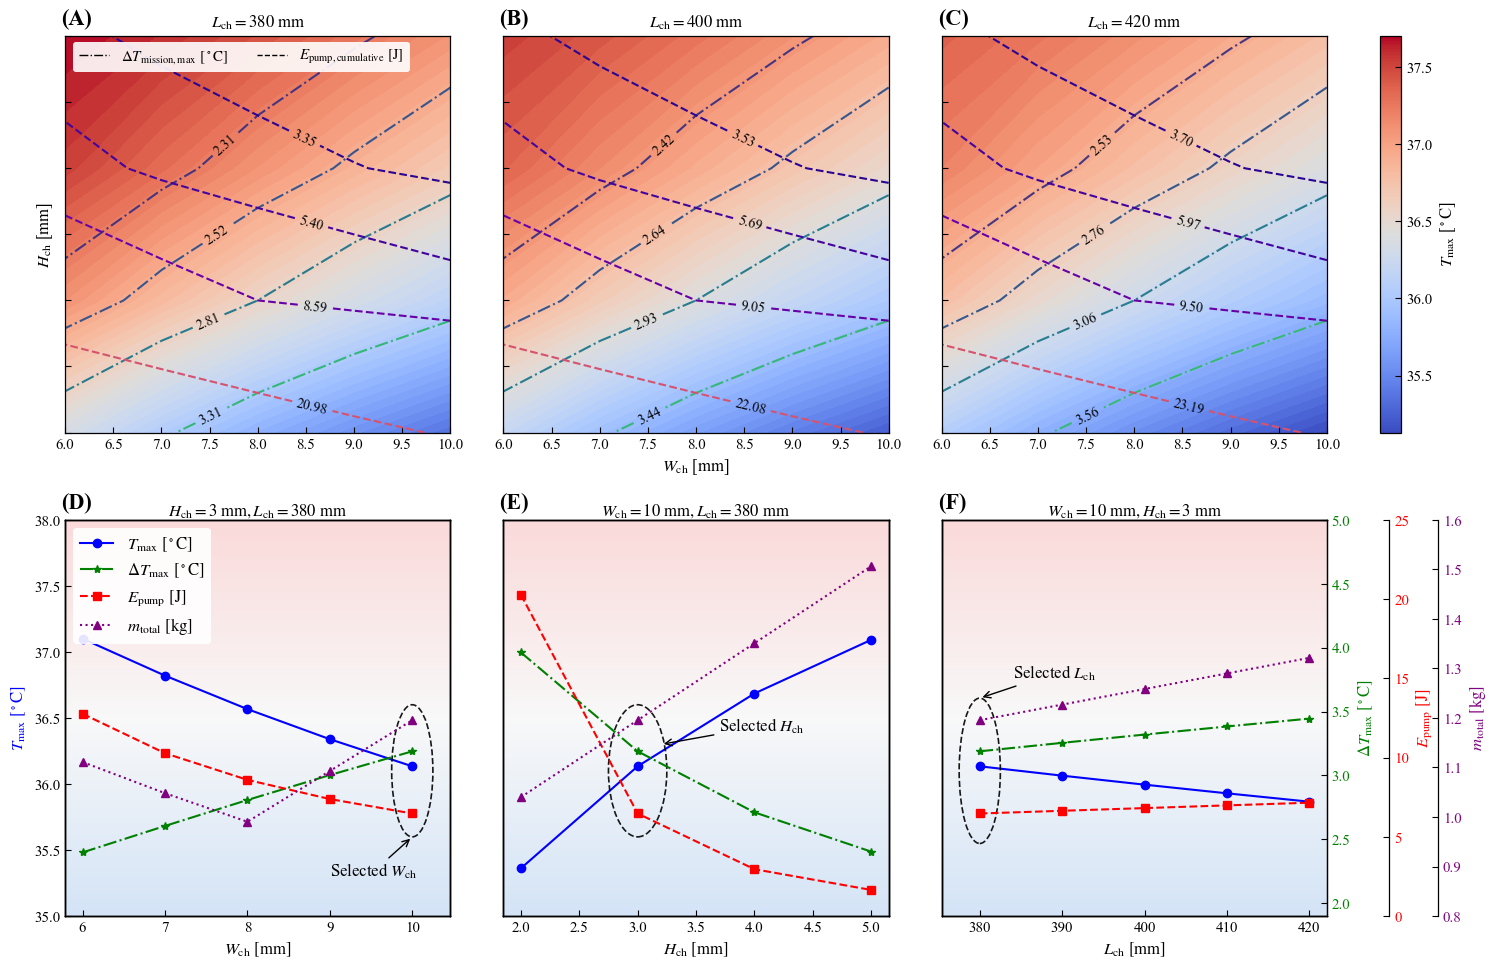

Combined plot saved to: d:\eBATS\out\C0003\C0003_PARK25_LC_1D_SCAN_plot_stage2.png
Combined plot saved to: d:\eBATS\out\C0003\C0003_PARK25_LC_1D_SCAN_plot_stage2.pdf


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import os
import sys
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse

# -----------------------------------------------------------------------------
# Data file and utility setup
# -----------------------------------------------------------------------------
root_dir = os.path.abspath("../..")
sys.path.append(root_dir)

import lib.plot_util as plot_util

CASE_ID = "C0003"
CASE_NAME = "C0003R03_PARK25_LC_1D_SCAN"
data_file = os.path.join(root_dir, "data", CASE_ID, f"{CASE_NAME}.xlsx")
sheet_name = "Geometry scan_stage2"
data = pd.read_excel(data_file, sheet_name=sheet_name)

for column in ['W_channel_mm', 'H_channel_mm', 'L_channel_mm', 'Tmax_mission_C', 'DeltaT_mission_max_C', 'E_pump_cumulative', 'mtotal']:
    data[column] = pd.to_numeric(data[column], errors='raise')

def label_fmt(x):
    return f"{x:.2f}"

# -----------------------------------------------------------------------------
# Plot style
# -----------------------------------------------------------------------------
base_fontsize = 12
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'stix',
    'font.size': base_fontsize,
    'axes.labelsize': base_fontsize,
    'axes.titlesize': base_fontsize,
    'xtick.labelsize': base_fontsize * 0.9,
    'ytick.labelsize': base_fontsize * 0.9,
    'axes.linewidth': 0.9,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'axes.unicode_minus': False,
})

# -----------------------------------------------------------------------------
# Create the combined A-F figure
# -----------------------------------------------------------------------------
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 4, width_ratios=[1.0, 1.0, 1.0, 0.055], height_ratios=[1.0, 1.0], left=0.065, right=0.90, bottom=0.075, top=0.955, wspace=0.18, hspace=0.22)
ax_A = fig.add_subplot(gs[0, 0])
ax_B = fig.add_subplot(gs[0, 1], sharex=ax_A, sharey=ax_A)
ax_C = fig.add_subplot(gs[0, 2], sharex=ax_A, sharey=ax_A)
cax = fig.add_subplot(gs[0, 3])
ax_D = fig.add_subplot(gs[1, 0])
ax_E = fig.add_subplot(gs[1, 1])
ax_F = fig.add_subplot(gs[1, 2])

# -----------------------------------------------------------------------------
# Top row: geometry-scan contour plots (A-C)
# -----------------------------------------------------------------------------
key_L = 'L_channel_mm'
key_x = 'W_channel_mm'
key_y = 'H_channel_mm'
key_val_T = 'Tmax_mission_C'
key_val_dT = 'DeltaT_mission_max_C'
key_val_E = 'E_pump_cumulative'
L_array = np.array([380.0, 400.0, 420.0])
T_min = data[key_val_T].min()
T_max = data[key_val_T].max()
cmap_T = sns.color_palette('coolwarm', as_cmap=True)
cmap_dT = sns.color_palette('viridis', as_cmap=True)
cmap_E = sns.color_palette('plasma', as_cmap=True)
ax_dict = [ax_A, ax_B, ax_C]

for i, L_channel in enumerate(L_array):
    ax = ax_dict[i]
    thermal_data = data[np.isclose(data[key_L], L_channel)].copy()
    x_values = np.sort(thermal_data[key_x].unique())
    y_values = np.sort(thermal_data[key_y].unique())
    Z_values_T = thermal_data.pivot(index=key_y, columns=key_x, values=key_val_T).reindex(index=y_values, columns=x_values).values
    Z_values_dT = thermal_data.pivot(index=key_y, columns=key_x, values=key_val_dT).reindex(index=y_values, columns=x_values).values
    Z_values_E = thermal_data.pivot(index=key_y, columns=key_x, values=key_val_E).reindex(index=y_values, columns=x_values).values
    dT_min = Z_values_dT.min()
    dT_max = Z_values_dT.max()
    E_min = Z_values_E.min()
    E_max = Z_values_E.max()
    target_y = np.linspace(y_values.min() + 0.3, y_values.max() - 0.6, 4)
    mid_col = len(x_values) // 2
    levels_dT = np.sort(np.interp(target_y, y_values, Z_values_dT[:, mid_col]))
    levels_E = np.sort(np.interp(target_y, y_values, Z_values_E[:, mid_col]))
    ax.contourf(x_values, y_values, Z_values_T, levels=50, cmap=cmap_T, vmin=T_min, vmax=T_max)
    cs_dT = ax.contour(x_values, y_values, Z_values_dT, levels=levels_dT, cmap=cmap_dT, vmin=dT_min, vmax=dT_max, linestyles='dashdot')
    cs_E = ax.contour(x_values, y_values, Z_values_E, levels=levels_E, cmap=cmap_E, vmin=E_min, vmax=E_max, linestyles='dashed')
    x_left = x_values[0] + 0.35 * (x_values[-1] - x_values[0])
    x_right = x_values[0] + 0.65 * (x_values[-1] - x_values[0])
    manual_dT = [(x_left, y) for y in target_y]
    manual_E = [(x_right, y) for y in target_y]
    ax.clabel(cs_dT, inline=True, fontsize=10, fmt=label_fmt, colors='black', manual=manual_dT)
    ax.clabel(cs_E, inline=True, fontsize=10, fmt=label_fmt, colors='black', manual=manual_E)
    if i != 0:
        ax.set_yticklabels([])
    else:
        ax.set_ylabel(r'$H_\mathrm{ch}$ [mm]')
    ax.set_title(rf'$L_\mathrm{{ch}}={L_channel:g}$ mm')
    ax.text(-0.01, 1.015, ['(A)', '(B)', '(C)'][i], transform=ax.transAxes, fontsize=16, fontweight='bold', va='bottom', ha='left', clip_on=False)

ax_B.set_xlabel(r'$W_\mathrm{ch}$ [mm]')
legend_elements = [
    Line2D([0], [0], color='black', lw=1, linestyle='dashdot', label=r'$\Delta T_\mathrm{mission,max}~[\mathrm{^\circ C}]$'),
    Line2D([0], [0], color='black', lw=1, linestyle='dashed', label=r'$E_\mathrm{pump,cumulative}~[\mathrm{J}]$'),
]
legend_top = ax_A.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0.02, 0.985), borderaxespad=0.0, ncol=2, fontsize=base_fontsize * 0.9, frameon=True, facecolor='white', edgecolor='none', framealpha=0.9)
legend_top.set_zorder(5)

sm = plt.cm.ScalarMappable(cmap=cmap_T, norm=Normalize(vmin=T_min, vmax=T_max))
sm.set_array([])
cb = fig.colorbar(sm, cax=cax)
cb.set_label(r'$T_{\max}$ [$^\circ$C]')

# -----------------------------------------------------------------------------
# Bottom row: detailed geometry effects (D-F)
# -----------------------------------------------------------------------------
y1_name = 'Tmax_mission_C'
y2_name = 'DeltaT_mission_max_C'
y3_name = 'E_pump_cumulative'
y4_name = 'mtotal'
Tbmax_range = [35, 38]
dTbmax_range = [1.9, 5]
Epump_range = [0, 25]
mtotal_range = [0.8, 1.6]
curve_artists = {
    y1_name: dict(color='blue', label=r'$T_\mathrm{max}~[^\circ \mathrm{C}]$', ls='-', marker='o'),
    y2_name: dict(color='green', label=r'$\Delta T_\mathrm{max}~[^\circ \mathrm{C}]$', ls='-.', marker='*'),
    y3_name: dict(color='red', label=r'$E_\mathrm{pump}~[\mathrm{J}]$', ls='--', marker='s'),
    y4_name: dict(color='purple', label=r'$m_\mathrm{total}~[\mathrm{kg}]$', ls=':', marker='^')
}
ax_all = [ax_D, ax_E, ax_F]

# (D) fixed Hch and Lch, varying Wch
H_ch = 3
L_ch = 380
filtered_data = data[(data['H_channel_mm'] == H_ch) & (data['L_channel_mm'] == L_ch)].sort_values('W_channel_mm')
ax_cur = ax_all[0]
ax_cur.plot(filtered_data['W_channel_mm'], filtered_data[y1_name], **curve_artists[y1_name])
ax_cur.set_xlabel(r'$W_\mathrm{ch}~[\mathrm{mm}]$')
ax_cur.set_ylabel(curve_artists[y1_name]['label'], color='blue')
ax_cur.set_ylim(Tbmax_range)
ax_cur.set_title(rf'$H_\mathrm{{ch}} = {H_ch}~\mathrm{{mm}}, L_\mathrm{{ch}} = {L_ch}~\mathrm{{mm}}$', pad=2)
W_ch = 10
T_target = 36.1
ax_cur.add_patch(Ellipse((W_ch, T_target), width=0.5, height=1.0, facecolor='none', edgecolor='black', linestyle='--', linewidth=1.2, alpha=0.9, zorder=5))
ax_cur.annotate(r'Selected $W_\mathrm{ch}$', xy=(W_ch, T_target - 0.5), xytext=(W_ch - 1.0, T_target - 0.8), textcoords='data', fontsize=12, color='black', arrowprops=dict(arrowstyle='->', color='black', lw=1))
ax2 = ax_cur.twinx()
ax2.plot(filtered_data['W_channel_mm'], filtered_data[y2_name], **curve_artists[y2_name])
ax2.set_yticklabels([])
ax2.set_yticks([])
ax2.set_ylim(dTbmax_range)
ax3 = ax_cur.twinx()
ax3.plot(filtered_data['W_channel_mm'], filtered_data[y3_name], **curve_artists[y3_name])
ax3.set_yticklabels([])
ax3.set_yticks([])
ax3.set_ylim(Epump_range)
ax4 = ax_cur.twinx()
ax4.plot(filtered_data['W_channel_mm'], filtered_data[y4_name], **curve_artists[y4_name])
ax4.set_yticklabels([])
ax4.set_yticks([])
ax4.set_ylim(mtotal_range)
plot_util.draw_plot_bg_gradient(ax_cur, *ax_cur.get_xlim(), *ax_cur.get_ylim())
lines, labels = ax_cur.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()
lines_all = lines + lines2 + lines3 + lines4
labels_all = labels + labels2 + labels3 + labels4
ax_cur.legend(lines_all, labels_all, loc='upper left', ncol=1, frameon=True, facecolor='white', edgecolor='none', framealpha=0.9)

# (E) fixed Wch and Lch, varying Hch
W_ch = 10
L_ch = 380
filtered_data = data[(data['W_channel_mm'] == W_ch) & (data['L_channel_mm'] == L_ch)].sort_values('H_channel_mm')
ax_cur = ax_all[1]
ax_cur.plot(filtered_data['H_channel_mm'], filtered_data[y1_name], **curve_artists[y1_name])
ax_cur.set_xlabel(r'$H_\mathrm{ch}~[\mathrm{mm}]$')
ax_cur.set_yticklabels([])
ax_cur.set_yticks([])
ax_cur.tick_params(axis='y', labelcolor='blue')
ax_cur.set_ylim(Tbmax_range)
ax_cur.set_title(rf'$W_\mathrm{{ch}} = {W_ch}~\mathrm{{mm}}, L_\mathrm{{ch}} = {L_ch}~\mathrm{{mm}}$', pad=2)
H_ch = 3
T_target = 36.1
ax_cur.add_patch(Ellipse((H_ch, T_target), width=0.5, height=1.0, facecolor='none', edgecolor='black', linestyle='--', linewidth=1.2, alpha=0.9, zorder=5))
ax_cur.annotate(r'Selected $H_\mathrm{ch}$', xy=(H_ch + 0.2, T_target + 0.2), xytext=(H_ch + 0.7, T_target + 0.3), textcoords='data', fontsize=12, color='black', arrowprops=dict(arrowstyle='->', color='black', lw=1))
ax2 = ax_cur.twinx()
ax2.plot(filtered_data['H_channel_mm'], filtered_data[y2_name], **curve_artists[y2_name])
ax2.set_yticklabels([])
ax2.set_yticks([])
ax2.set_ylim(dTbmax_range)
ax3 = ax_cur.twinx()
ax3.plot(filtered_data['H_channel_mm'], filtered_data[y3_name], **curve_artists[y3_name])
ax3.set_yticklabels([])
ax3.set_yticks([])
ax3.set_ylim(Epump_range)
ax4 = ax_cur.twinx()
ax4.plot(filtered_data['H_channel_mm'], filtered_data[y4_name], **curve_artists[y4_name])
ax4.set_yticklabels([])
ax4.set_yticks([])
ax4.set_ylim(mtotal_range)
plot_util.draw_plot_bg_gradient(ax_cur, *ax_cur.get_xlim(), *ax_cur.get_ylim())

# (F) fixed Wch and Hch, varying Lch
W_ch = 10
H_ch = 3
filtered_data = data[(data['W_channel_mm'] == W_ch) & (data['H_channel_mm'] == H_ch)].sort_values('L_channel_mm')
ax_cur = ax_all[2]
ax_cur.plot(filtered_data['L_channel_mm'], filtered_data[y1_name], **curve_artists[y1_name])
ax_cur.set_xlabel(r'$L_\mathrm{ch}~[\mathrm{mm}]$')
ax_cur.set_yticklabels([])
ax_cur.set_yticks([])
ax_cur.set_ylim(Tbmax_range)
ax_cur.set_title(rf'$W_\mathrm{{ch}} = {W_ch}~\mathrm{{mm}}, H_\mathrm{{ch}} = {H_ch}~\mathrm{{mm}}$', pad=2)
L_ch = 380
T_target = 36.1
ax_cur.add_patch(Ellipse((L_ch, T_target), width=5, height=1.1, facecolor='none', edgecolor='black', linestyle='--', linewidth=1.2, alpha=0.9, zorder=5))
ax_cur.annotate(r'Selected $L_\mathrm{ch}$', xy=(L_ch, T_target + 0.55), xytext=(L_ch + 4, T_target + 0.7), textcoords='data', fontsize=12, color='black', arrowprops=dict(arrowstyle='->', color='black', lw=1))
ax2 = ax_cur.twinx()
ax2.plot(filtered_data['L_channel_mm'], filtered_data[y2_name], **curve_artists[y2_name])
ax2.set_ylabel(curve_artists[y2_name]['label'], color=curve_artists[y2_name]['color'])
ax2.tick_params(axis='y', labelcolor=curve_artists[y2_name]['color'])
ax2.set_ylim(dTbmax_range)
ax3 = ax_cur.twinx()
ax3.spines['right'].set_position(('outward', 45))
ax3.plot(filtered_data['L_channel_mm'], filtered_data[y3_name], **curve_artists[y3_name])
ax3.set_ylabel(curve_artists[y3_name]['label'], color=curve_artists[y3_name]['color'])
ax3.tick_params(axis='y', labelcolor=curve_artists[y3_name]['color'])
ax3.set_ylim(Epump_range)
ax4 = ax_cur.twinx()
ax4.spines['right'].set_position(('outward', 80))
ax4.plot(filtered_data['L_channel_mm'], filtered_data[y4_name], **curve_artists[y4_name])
ax4.set_ylabel(curve_artists[y4_name]['label'], color=curve_artists[y4_name]['color'])
ax4.tick_params(axis='y', labelcolor=curve_artists[y4_name]['color'])
ax4.set_ylim(mtotal_range)
plot_util.draw_plot_bg_gradient(ax_cur, *ax_cur.get_xlim(), *ax_cur.get_ylim())

for ax, panel_label in zip(ax_all, ['(D)', '(E)', '(F)']):
    ax.text(-0.01, 1.015, panel_label, transform=ax.transAxes, fontsize=16, fontweight='bold', va='bottom', ha='left', clip_on=False)

plt.show()

# -----------------------------------------------------------------------------
# Save the combined figure
# -----------------------------------------------------------------------------
output_folder = os.path.join(root_dir, 'out', CASE_ID)
os.makedirs(output_folder, exist_ok=True)
output_png = os.path.join(output_folder, 'C0003_PARK25_LC_1D_SCAN_plot_stage2.png')
output_pdf = os.path.join(output_folder, 'C0003_PARK25_LC_1D_SCAN_plot_stage2.pdf')
fig.savefig(output_png, dpi=300, bbox_inches='tight')
fig.savefig(output_pdf, dpi=300, bbox_inches='tight')
print(f'Combined plot saved to: {output_png}')
print(f'Combined plot saved to: {output_pdf}')


